
# Fee-Capped Transaction Landing Prediction on Solana
## Learning a Low-Latency Sender Policy

**Student:** Ryan Rebbas 
**Course:** COMP 432  
**Project type:** Individual machine learning project  

### Abstract
This research aims to predict the probability of a transaction confirmation on Solana within a certain number of slots when there is a strict fee cap applied, as well as the delay between submitting a transaction and confirming it when the transaction has been successfully added to the blockchain. The goal here is to determine execution efficiency, not the effectiveness of any particular trading strategy – namely, can we send a transaction more efficiently than using constant or recent fees?

This notebook utilizes supervised learning on transaction data, which is tabular and time-series. It compares models that are easy to interpret and complex models. It uses a time-based split of the data to prevent data leakage. We consider not only the predictive ability but also the quality of decisions made by the model.



## 1. Importance of the Project

Transactions in the Solana network land in a setting characterized by dynamic congestion, fees, transaction structure, and routing. When fees are too low, the transaction can miss the designated slot window or require retransmission; conversely, when fees are too high, the gain may be reduced or lost altogether. Thus, the problem of bounded-fees landing prediction is a good candidate for machine learning: it is measurable, real-world, and does not involve proprietary trading algorithms.

### Research questions
1. Will machine learning methods be able to predict whether a transaction lands in K ∈ {1, 2, 3} slots more precisely than simple baselines?
2. Will machine learning be capable of predicting confirmation delays for successfully landed transactions and thereby informing senders about their decision-making strategy?
3. Is there any benefit in adopting an ML-driven threshold policy to optimize the trade-off between success probability, latency, and fee prioritization?

### Main hypotheses
- Tree-based nonlinear models will perform better than baseline linear ones because the interplay of fee size, network load, and transaction content is inherently nonlinear.
- Chronologically separated validation will give a more realistic estimate than random partitioning of the data.
- Decision-oriented evaluation is crucial, whereas metrics alone are secondary, as the underlying issue is operational, not purely theoretical.


2. Originality and scope

This project neither attempts to forecast the prices of tokens nor create any kind of strategy. Instead, it is concerned with the narrower and safer goal of evaluating execution quality with a strict fee limit.

The aspects making it original in this class include the following:
- The emphasis on Solana transaction arrival and latency rather than a standard Kaggle baseline.
- Features restricted to those known at the moment of transmission.
- Evaluation scheme with prediction-based measurements and offline sender policy assessment.
- Deliberate consideration of non-stationarity and leakage as key threats of this task.



## 3. Reproducibility checklist

- Clear problem statement and measurable outcomes.
- Explicit dataset schema.
- Chronological train/validation/test split.
- Multiple models and baselines.
- Honest conclusion.
- Modular code stored outside the notebook.


## 3A [Optional]: Real-data collection workflow

The helper code is merged into a single public module so the package is not scattered across several standalone scripts. Run the following script if you decide that you wish to generate the data yourself (you migh have to fund the generated wallet with a bit of real solana) then run the suggested commands to generate a solana wallet, send mass trnasaction and pre process the data. This part is optional as data in csv format is available at the following web address: https://github.com/TheMasterProgrammer/COMP-432-Project . Make sure to download solana_execution_quality.py. if you want to re use the same data we used for training simply download real_transactions_prepared.csv finally put all the files in the same working directory as this current notebook

In [6]:
# Optional helper commands for real data collection.
# Do not run these cells unless you want to build a real dataset.

from pathlib import Path

WINDOWS_KEYPAIR_PATH = Path.home() / ".config" / "solana" / "id.json"

print("Suggested keypair path:", WINDOWS_KEYPAIR_PATH)
print("Unified helper: python solana_execution_quality.py generate-keypair --output", WINDOWS_KEYPAIR_PATH)
print("Collect real data: python solana_execution_quality.py collect-real-data --rpc-url https://api.mainnet-beta.solana.com --keypair", WINDOWS_KEYPAIR_PATH, "--output real_transactions.csv --num-samples 300 --lamports 1 --fee-cap-lamports 20 --sleep-seconds 1.0")
print("Prepare dataset: python solana_execution_quality.py prepare-real-data --input real_transactions.csv --output real_transactions_prepared.csv")

Suggested keypair path: C:\Users\ryan\.config\solana\id.json
Unified helper: python solana_execution_quality.py generate-keypair --output C:\Users\ryan\.config\solana\id.json
Collect real data: python solana_execution_quality.py collect-real-data --rpc-url https://api.mainnet-beta.solana.com --keypair C:\Users\ryan\.config\solana\id.json --output real_transactions.csv --num-samples 300 --lamports 1 --fee-cap-lamports 20 --sleep-seconds 1.0
Prepare dataset: python solana_execution_quality.py prepare-real-data --input real_transactions.csv --output real_transactions_prepared.csv


In [ ]:

# Optional Colab installs
# Run this if you are running this in a fresh Colab runtime.
!pip install -q pandas numpy scikit-learn matplotlib requests pyarrow


Click run to import the necessary libraries

In [5]:

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from solana_execution_quality import (
    BASE_CATEGORICAL_FEATURES,
    BASE_NUMERIC_FEATURES,
    RawLogDatasetBuilder,
    SolanaRpcClient,
    add_calendar_features,
    build_policy_table,
    generate_synthetic_demo_dataset,
    plot_probability_histogram,
    plot_regression_scatter,
    summarize_congestion_regimes,
    time_based_split,
    train_and_evaluate_classifiers,
    train_and_evaluate_regressors,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)



## 4. Configuration

### Expected dataset columns
At minimum, the modeling dataset should contain:
- `timestamp_utc`
- `send_method`
- `cu_limit`
- `cu_price_micro_lamports`
- `priority_fee_lamports`
- `fee_cap_lamports`
- `recent_fee_min`, `recent_fee_median`, `recent_fee_p90`, `recent_fee_max`
- `recent_tps`, `recent_slots_per_second`
- `message_size_bytes`, `instruction_count`, `account_count`, `writable_account_count`
- `landed_within_1_slots`, `landed_within_2_slots`, `landed_within_3_slots`
- `latency_ms`


In [7]:

DEMO_RANDOM_STATE = 42

PROJECT_DIR = Path('.')
REAL_DATA_PATH = PROJECT_DIR / 'real_transactions_prepared.csv'

if not REAL_DATA_PATH.exists():
    raise FileNotFoundError(
        'real_transactions_prepared.csv was not found. Place your real dataset beside this notebook '
    )
df = pd.read_csv(REAL_DATA_PATH, parse_dates=['timestamp_utc'])
df = add_calendar_features(df)

print(df.shape)
df.head()


(722, 29)


,timestamp_utc,send_method,cu_limit,cu_price_micro_lamports,priority_fee_lamports,fee_cap_lamports,recent_fee_min,recent_fee_median,recent_fee_p90,recent_fee_max,recent_tps,recent_slots_per_second,message_size_bytes,instruction_count,account_count,writable_account_count,landed_within_1_slots,landed_within_2_slots,landed_within_3_slots,latency_ms,slot_delta,confirmation_status,rpc_status_has_error,signature,sent_slot,landed_slot,time_of_day_sin,time_of_day_cos,day_of_week
0,2026-04-15 00:19:43.583499+00:00,rpc,200000,1,1,20,0.0,0.0,0.0,0.0,2988.336667,2.525833,237,3,3,1,0,1,1,1406.0,2.0,confirmed,0,3x2QcPhrPW3ZbeoQGd2LFpGdg65VPFUw5Aiot2ZHJPoFiM...,413272051,413272053.0,0.085924,0.996302,2
1,2026-04-15 00:19:46.890476+00:00,rpc,160000,1,1,20,0.0,0.0,0.0,0.0,2988.336667,2.525833,237,3,3,1,0,1,1,1406.0,2.0,confirmed,0,5PqFEf6S78KZCyDpfAspoUCgHDR2E7byAagbmn9pzuiTvB...,413272059,413272061.0,0.086141,0.996283,2
2,2026-04-15 00:20:33.936260+00:00,rpc,200000,1,1,20,0.0,0.0,0.0,0.0,2988.336667,2.525833,237,3,3,1,0,0,0,2313.0,5.0,confirmed,0,4MSQimdgngWg3QaVGEFuAUSFAXjgiv7wAbhWSYtFUgTkEV...,413272178,413272183.0,0.089546,0.995983,2
3,2026-04-15 00:20:38.173302+00:00,rpc,160000,1,1,20,0.0,0.0,0.0,0.0,2975.500000,2.527500,237,3,3,1,0,1,1,500.0,2.0,processed,0,3w5azgpL6UHBkYJy1yJyAZqEYySgmtnzXigFSVbCvyKM5U...,413272189,413272191.0,0.089908,0.995950,2
4,2026-04-15 00:20:40.571776+00:00,rpc,250000,1,1,20,0.0,0.0,0.0,0.0,2975.500000,2.527500,237,3,3,1,0,0,0,2297.0,5.0,confirmed,0,pJv92q5i7DWpDbzCkcTQxp6GKTwwB2o4HcbLJLjPWsxwz6...,413272195,413272200.0,0.090053,0.995937,2



## 5. First data audit
Before training anything, we verify the basic shape of the problem and check whether the labels and features look sensible.


In [8]:

summary_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_fraction': df.isna().mean().round(4),
    'n_unique': df.nunique(),
}).sort_index()
summary_table.head(30)


,dtype,missing_fraction,n_unique
account_count,int64,0.0,1
confirmation_status,object,0.0,2
cu_limit,int64,0.0,5
cu_price_micro_lamports,int64,0.0,1
day_of_week,int32,0.0,1
fee_cap_lamports,int64,0.0,1
instruction_count,int64,0.0,1
landed_slot,float64,0.0,722
landed_within_1_slots,int64,0.0,2
landed_within_2_slots,int64,0.0,2


In [5]:

label_summary = pd.DataFrame({
    'landed_within_1_slots_rate': [df['landed_within_1_slots'].mean()],
    'landed_within_2_slots_rate': [df['landed_within_2_slots'].mean()],
    'landed_within_3_slots_rate': [df['landed_within_3_slots'].mean()],
    'median_latency_ms': [df['latency_ms'].median()],
    'avg_priority_fee_lamports': [df['priority_fee_lamports'].mean()],
})
label_summary


,landed_within_1_slots_rate,landed_within_2_slots_rate,landed_within_3_slots_rate,median_latency_ms,avg_priority_fee_lamports
0,0.030417,0.07575,0.144,2448.845,12.90825


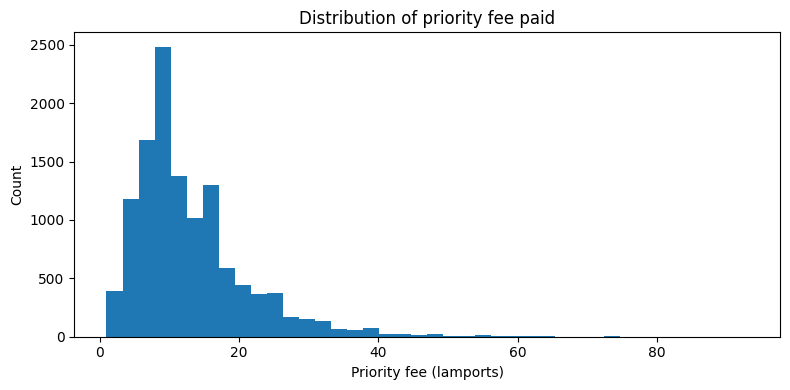

In [6]:

fig = plt.figure(figsize=(8, 4))
plt.hist(df['priority_fee_lamports'], bins=40)
plt.title('Distribution of priority fee paid')
plt.xlabel('Priority fee (lamports)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


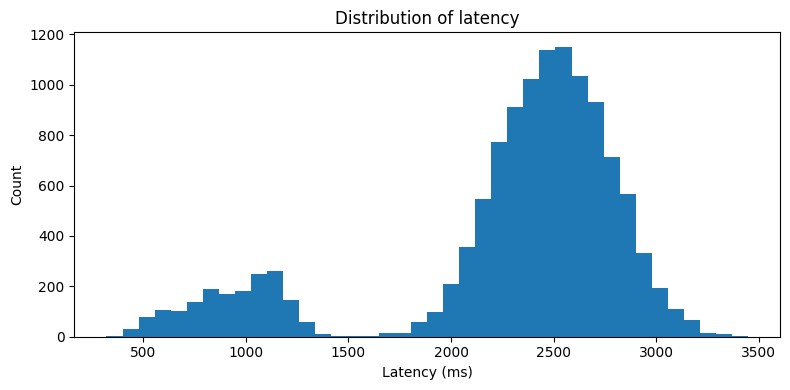

In [7]:

fig = plt.figure(figsize=(8, 4))
plt.hist(df['latency_ms'], bins=40)
plt.title('Distribution of latency')
plt.xlabel('Latency (ms)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



## 6. Leakage prevention and time split
A random split will cause the model to learn from future congestion scenarios, thus giving an overly optimistic estimate of performance. Since non-stationarity is already pointed out as an issue by the proposal, a strict chronological split is used instead.


In [8]:

split = time_based_split(df, timestamp_column='timestamp_utc', train_fraction=0.70, val_fraction=0.15)

split_overview = pd.DataFrame([
    {
        'split': 'train',
        'rows': len(split.train),
        'start': split.train['timestamp_utc'].min(),
        'end': split.train['timestamp_utc'].max(),
    },
    {
        'split': 'validation',
        'rows': len(split.val),
        'start': split.val['timestamp_utc'].min(),
        'end': split.val['timestamp_utc'].max(),
    },
    {
        'split': 'test',
        'rows': len(split.test),
        'start': split.test['timestamp_utc'].min(),
        'end': split.test['timestamp_utc'].max(),
    },
])
split_overview


,split,rows,start,end
0,train,8400,2026-01-01 00:00:00+00:00,2026-01-30 03:55:00+00:00
1,validation,1800,2026-01-30 04:00:00+00:00,2026-02-05 09:55:00+00:00
2,test,1800,2026-02-05 10:00:00+00:00,2026-02-11 15:55:00+00:00



## 7. Feature set
Features are limited to values available at send time.

### Numeric features
- fee cap and chosen compute budget parameters
- recent fee statistics
- recent performance samples
- transaction size and structure
- calendar features

### Categorical feature
- send path (`rpc`, `tpu`, or `both`)


In [9]:

FEATURE_COLUMNS = BASE_NUMERIC_FEATURES + BASE_CATEGORICAL_FEATURES
CLASSIFICATION_TARGETS = [
    'landed_within_1_slots',
    'landed_within_2_slots',
    'landed_within_3_slots',
]

FEATURE_COLUMNS


['cu_limit',
 'cu_price_micro_lamports',
 'priority_fee_lamports',
 'fee_cap_lamports',
 'recent_fee_min',
 'recent_fee_median',
 'recent_fee_p90',
 'recent_fee_max',
 'recent_tps',
 'recent_slots_per_second',
 'message_size_bytes',
 'instruction_count',
 'account_count',
 'writable_account_count',
 'time_of_day_sin',
 'time_of_day_cos',
 'day_of_week',
 'send_method']


## 8. Classification experiments
We compare three models:
1. **Logistic regression** as an interpretable baseline.
2. **Random forest** as a robust nonlinear baseline.
3. **Extra trees** as another strong nonlinear ensemble.

The main classification targets are whether the transaction lands within **1**, **2**, or **3** slots.


In [10]:

classification_tables = []
fitted_classifiers = {}
probability_store = {}

for target in CLASSIFICATION_TARGETS:
    table, models, prob_map = train_and_evaluate_classifiers(
        train_frame=split.train,
        test_frame=split.test,
        target_name=target,
        feature_columns=FEATURE_COLUMNS,
        numeric_features=BASE_NUMERIC_FEATURES,
        categorical_features=BASE_CATEGORICAL_FEATURES,
    )
    classification_tables.append(table)
    fitted_classifiers[target] = models
    probability_store[target] = prob_map

classification_results = pd.concat(classification_tables, ignore_index=True)
classification_results


,model,target,roc_auc,average_precision,brier_score,positive_rate,baseline_positive_rate
0,random_forest,landed_within_1_slots,0.736095,0.103170,0.047367,0.005000,0.030000
1,logistic_regression,landed_within_1_slots,0.722381,0.084324,0.211882,0.353333,0.030000
2,extra_trees,landed_within_1_slots,0.682884,0.100494,0.070941,0.014444,0.030000
3,random_forest,landed_within_2_slots,0.737786,0.193825,0.100766,0.051111,0.075556
4,logistic_regression,landed_within_2_slots,0.736036,0.184003,0.217325,0.395000,0.075556
5,extra_trees,landed_within_2_slots,0.723226,0.200990,0.133632,0.096111,0.075556
6,logistic_regression,landed_within_3_slots,0.720404,0.314373,0.217016,0.417222,0.152222
7,random_forest,landed_within_3_slots,0.718495,0.326974,0.150580,0.147222,0.152222
8,extra_trees,landed_within_3_slots,0.702571,0.310786,0.179009,0.224444,0.152222



### Interpretation
For an A-level discussion, do not just report the best number. Explain **why** a model might work better and connect it to the structure of the problem. For example:
- If the tree models win, that supports the idea that congestion/fee interactions are nonlinear.
- If logistic regression remains competitive, then the system may be simpler than expected.
- If all models are weak, that suggests the feature set is missing important signals or the environment is highly unstable.


Best K=3 model: logistic_regression


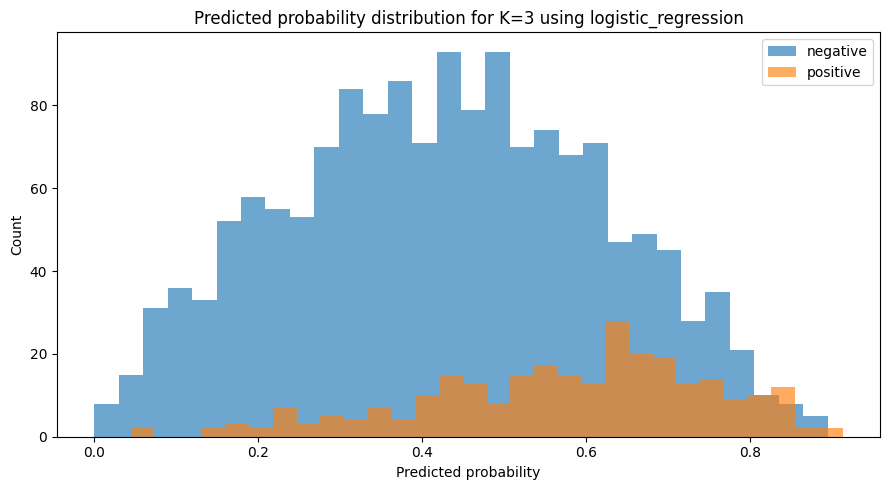

In [11]:

# Choose the best K=3 model for deeper analysis.
k3_results = classification_results[classification_results['target'] == 'landed_within_3_slots'].copy()
best_k3_model_name = k3_results.sort_values('roc_auc', ascending=False).iloc[0]['model']
print('Best K=3 model:', best_k3_model_name)

split.test = split.test.copy()
split.test['pred_p_k3'] = probability_store['landed_within_3_slots'][best_k3_model_name]
plot_probability_histogram(
    probabilities=split.test['pred_p_k3'].to_numpy(),
    target=split.test['landed_within_3_slots'],
    title=f'Predicted probability distribution for K=3 using {best_k3_model_name}',
)



## 9. Regression experiment for latency
Latency is modeled only on transactions that actually landed within 3 slots. This keeps the target meaningful and avoids mixing successful confirmations with effectively censored failures.


In [12]:

train_landed = split.train[split.train['landed_within_3_slots'] == 1].copy()
test_landed = split.test[split.test['landed_within_3_slots'] == 1].copy()

regression_results, fitted_regressors, latency_predictions = train_and_evaluate_regressors(
    train_frame=train_landed,
    test_frame=test_landed,
    feature_columns=FEATURE_COLUMNS,
    numeric_features=BASE_NUMERIC_FEATURES,
    categorical_features=BASE_CATEGORICAL_FEATURES,
    target_name='latency_ms',
)
regression_results


,model,target,mae_ms,median_ae_ms,r2
0,extra_trees_regressor,latency_ms,175.209369,170.418711,0.149397
1,random_forest_regressor,latency_ms,176.433050,171.222944,0.139686


Best latency model: extra_trees_regressor


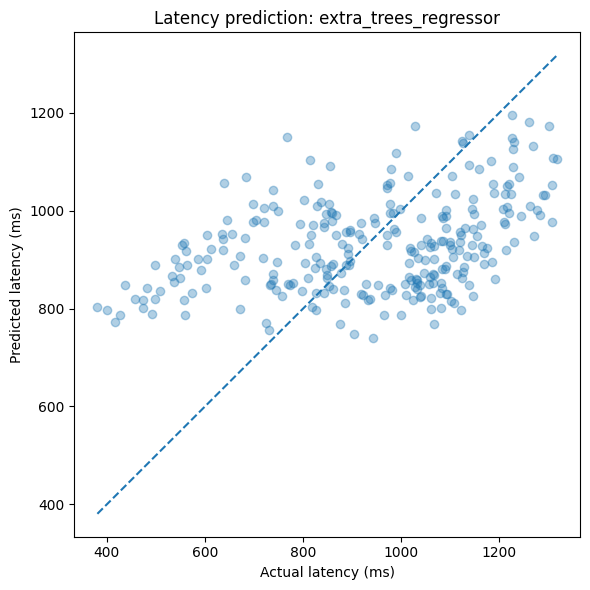

In [13]:

best_regression_model_name = regression_results.sort_values('mae_ms').iloc[0]['model']
print('Best latency model:', best_regression_model_name)
plot_regression_scatter(
    actual=test_landed['latency_ms'],
    predicted=latency_predictions[best_regression_model_name],
    title=f'Latency prediction: {best_regression_model_name}',
)



## 10. Decision-level policy analysis
A useful project should evaluate the model as a **decision tool**, not only as a predictor. Here the model induces a simple send/no-send policy:
- If predicted probability of landing within 3 slots is at least a threshold `τ`, accept the candidate send.
- Otherwise, reject it.

This is not the only possible policy, but it is transparent and easy to defend.


In [14]:

policy_table = build_policy_table(
    test_frame=split.test,
    probability_column='pred_p_k3',
    thresholds=[0.50, 0.60, 0.70, 0.80, 0.90],
    target_column='landed_within_3_slots',
    latency_column='latency_ms',
    fee_column='priority_fee_lamports',
)
policy_table


,threshold,acceptance_rate,success_rate,median_latency_ms,avg_priority_fee_lamports
0,0.5,0.417222,0.254328,2282.74,10.087883
1,0.6,0.246111,0.309255,2236.50,10.022573
2,0.7,0.110556,0.351759,2136.86,9.924623
3,0.8,0.029444,0.490566,1863.96,9.811321
4,0.9,0.000556,1.000000,977.28,8.000000


In [15]:

# Baseline references for discussion.
all_send_baseline = pd.DataFrame([
    {
        'policy': 'send_everything_under_cap',
        'acceptance_rate': 1.0,
        'success_rate': split.test['landed_within_3_slots'].mean(),
        'median_latency_ms': split.test['latency_ms'].median(),
        'avg_priority_fee_lamports': split.test['priority_fee_lamports'].mean(),
    },
    {
        'policy': 'recent_fee_p90_guardrail',
        'acceptance_rate': (split.test['cu_price_micro_lamports'] >= split.test['recent_fee_p90']).mean(),
        'success_rate': split.test.loc[
            split.test['cu_price_micro_lamports'] >= split.test['recent_fee_p90'],
            'landed_within_3_slots'
        ].mean(),
        'median_latency_ms': split.test.loc[
            split.test['cu_price_micro_lamports'] >= split.test['recent_fee_p90'],
            'latency_ms'
        ].median(),
        'avg_priority_fee_lamports': split.test.loc[
            split.test['cu_price_micro_lamports'] >= split.test['recent_fee_p90'],
            'priority_fee_lamports'
        ].mean(),
    },
])
all_send_baseline


,policy,acceptance_rate,success_rate,median_latency_ms,avg_priority_fee_lamports
0,send_everything_under_cap,1.000000,0.152222,2431.240,12.417222
1,recent_fee_p90_guardrail,0.528889,0.190126,2433.955,14.901261



### How to discuss this section well
A strong write-up does not just say “higher threshold is better.” It explains the tradeoff:
- Higher threshold usually lowers acceptance rate.
- But accepted transactions may have better landing probability and lower latency.
- The best policy depends on what matters most: coverage, reliability, or fee efficiency.



## 11. Error analysis by congestion regime
A realistic blockchain model should not only be judged by overall averages. It should also be checked across different network conditions.


In [16]:

regime_summary = summarize_congestion_regimes(split.test, target_column='landed_within_3_slots')
regime_summary


,regime,n,success_rate,median_latency_ms,avg_priority_fee_lamports
0,low,600,0.218333,2260.055,6.815000
1,medium,600,0.135000,2422.805,10.978333
2,high,600,0.103333,2605.815,19.458333


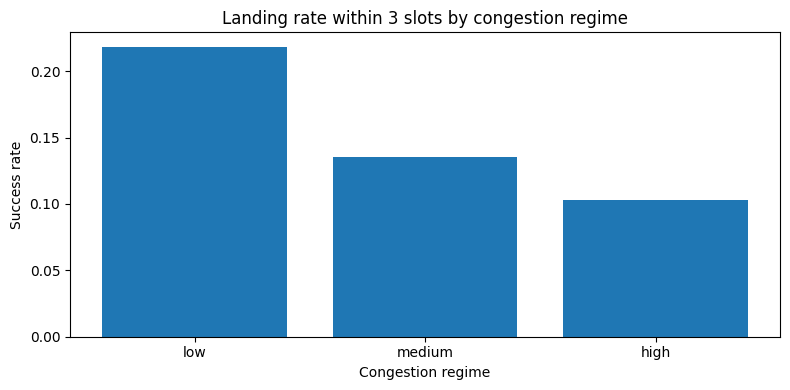

In [17]:

fig = plt.figure(figsize=(8, 4))
plt.bar(regime_summary['regime'].astype(str), regime_summary['success_rate'])
plt.title('Landing rate within 3 slots by congestion regime')
plt.xlabel('Congestion regime')
plt.ylabel('Success rate')
plt.tight_layout()
plt.show()



## 12. What to write in the final discussion
Use this section after running on your real dataset.

### Suggested discussion points
1. **Predictive quality**  
   Which model won for K=1, K=2, and K=3? Was the gain meaningful or marginal?

2. **Operational usefulness**  
   Did a threshold policy improve the success/latency/fee tradeoff relative to the simple baselines?

3. **Non-stationarity**  
   Did performance degrade on the latest time window? If yes, discuss why retraining frequency matters.

4. **Feature value**  
   Which features seemed most important? Did recent fee statistics and send path help as expected?

5. **Limitations**  
   Mention at least these:
   - labels are imperfect because commitment states differ;
   - offline evaluation is not identical to live decision-making;
   - missing mempool-level information may cap performance.



## 13. Honest conclusion template
Replace the bracketed parts after running the notebook on your real data.

> In this project, I studied whether send-time features can predict fee-capped Solana landing quality. Using a strict chronological split, I found that **[best model]** achieved the strongest performance for **[target]**, with **[metric values]**. Compared with simple baselines, the model-based threshold policy **[improved / did not improve]** the tradeoff among success rate, latency, and fee paid. These results suggest that **[main conclusion]**, although performance remains limited by **[main limitation]**. Overall, the project shows that execution-quality modeling is a feasible and meaningful machine learning problem on Solana.



## 14. Appendix: building a real dataset from raw sender logs
The support module contains a `RawLogDatasetBuilder` that can turn a raw log into a model dataset.

### Example expected raw log columns
- `signature`
- `sent_at_utc`
- `sent_slot`
- `send_method`
- `cu_limit`
- `cu_price_micro_lamports`
- `fee_cap_lamports`
- `message_size_bytes`
- `instruction_count`
- `account_count`
- `writable_account_count`

You can snapshot fee/performance signals at send time, poll statuses later, and then export the final dataset to `real_transactions.csv`.


In [18]:

# Example only. Do not run unless you have a real sender log and a working RPC endpoint.
#
# RAW_LOG_PATH = Path('raw_sender_log.csv')
# RPC_URL = 'https://api.mainnet-beta.solana.com'
#
# raw_logs = pd.read_csv(RAW_LOG_PATH)
# builder = RawLogDatasetBuilder(rpc_url=RPC_URL)
# labeled = builder.attach_labels_from_statuses(raw_logs)
# labeled = add_calendar_features(labeled.rename(columns={'sent_at_utc': 'timestamp_utc'}))
# labeled.to_csv('real_transactions.csv', index=False)



## 15. Sources and acknowledgements
This project package was written to match the approved proposal and course requirements. The core RPC logic is based on official Solana JSON-RPC documentation for:
- `getRecentPrioritizationFees`
- `getSignatureStatuses`
- `getRecentPerformanceSamples`
- Solana fee / compute budget rules

No external repository code is copied into the core project logic here. If you later borrow helper code from any repository, acknowledge it clearly in the notebook and in the imported module docstrings.
